In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import importlib
import mdata_utils

2025-11-03 14:21:40.463518: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-03 14:21:40.463874: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-03 14:21:40.517203: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-03 14:21:51.020805: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
importlib.reload(mdata_utils)

<module 'mdata_utils' from '/ihome/ylee/yiz133/Code/Data processing/functions/mdata_utils.py'>

# Merge the data

In [4]:
%cd "/ix1/ylee/Yifan_Zhang/Code_data/external"

/ix1/ylee/Yifan_Zhang/Code_data/external


In [5]:
from pathlib import Path
import re

# Get all folders that don't start with '_'
current_dir = Path('.')
folders = [f for f in current_dir.iterdir() if f.is_dir() and not f.name.startswith('_')]

# Load yz_processed.h5mu from each folder into named variables
mdata_dict = {}
mdata_list = []

n_top_genes = 200

for folder in folders:
    h5mu_file = folder / 'yz_processed_allGenes_annotateByScore.h5mu'
    
    if h5mu_file.exists():
        print(f"Loading: {h5mu_file}")
        mdata = mu.read(h5mu_file)
        var_name = re.sub(r'[^\w]', '_', folder.name) + '_mdata'
        
        # # reduce number of vars
        # sc.pp.highly_variable_genes(mdata['gex'], n_top_genes=n_top_genes)
        # mdata.mod['gex'] = mdata['gex'][:, mdata['gex'].var['highly_variable']].copy()
        # mdata = mdata_utils.sync_mdata_obs(mdata)
            
        # Store in dictionary and list
        mdata_dict[var_name] = mdata
        globals()[var_name] = mdata  # Create variable in global namespace
        mdata_list.append(mdata)

    else:
        print(f"Skipping {folder.name}: yz_processed.h5mu not found")

Loading: GSE1 LEE/yz_processed_allGenes_annotateByScore.h5mu
Loading: GSE156718 CD4 iLN/yz_processed_allGenes_annotateByScore.h5mu
Loading: GSE182747 CNS young and old/yz_processed_allGenes_annotateByScore.h5mu
Loading: GSE293883 CD4 Tr mem day60/yz_processed_allGenes_annotateByScore.h5mu
Loading: GSE178085 Bcl6KO_R Th17/yz_processed_allGenes_annotateByScore.h5mu
Loading: GSE188320 Th17/yz_processed_allGenes_annotateByScore.h5mu


In [6]:
import mudata as md

merged = mdata_utils.merge_mdatas(mdata_list, mods=["gex","airr"], keep_obs_columns="common", index_unique=None)
merged

MuData object with n_obs × n_vars = 142936 × 16481
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'condition', 'sample_id', 'state'
  2 modalities
    airr:	142936 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition'
      obsm:	'airr', 'chain_indices'
    gex:	142936 x 16481
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch'
      var:	'gene_ids', 'feature_types'

In [7]:
# reduce number of vars
sc.pp.highly_variable_genes(merged['gex'], n_top_genes=5000)
merged.mod['gex'] = merged['gex'][:, merged['gex'].var['highly_variable']].copy()
merged = mdata_utils.sync_mdata_obs(merged)
        
GEX_df = merged['gex'].to_df()
# GEX_df

# cluster by GEX

In [9]:
sc.pp.pca(merged["gex"], n_comps=50)

### no batch correction

In [10]:
sc.pp.neighbors(merged["gex"], n_neighbors = 50)
sc.tl.umap(merged["gex"], min_dist=0.5, spread=1.0)
sc.tl.leiden(merged["gex"], resolution = 1, n_iterations=-1, flavor = 'igraph')

In [11]:
merged["gex"].obs['GSE'] = merged.obs['GSE']

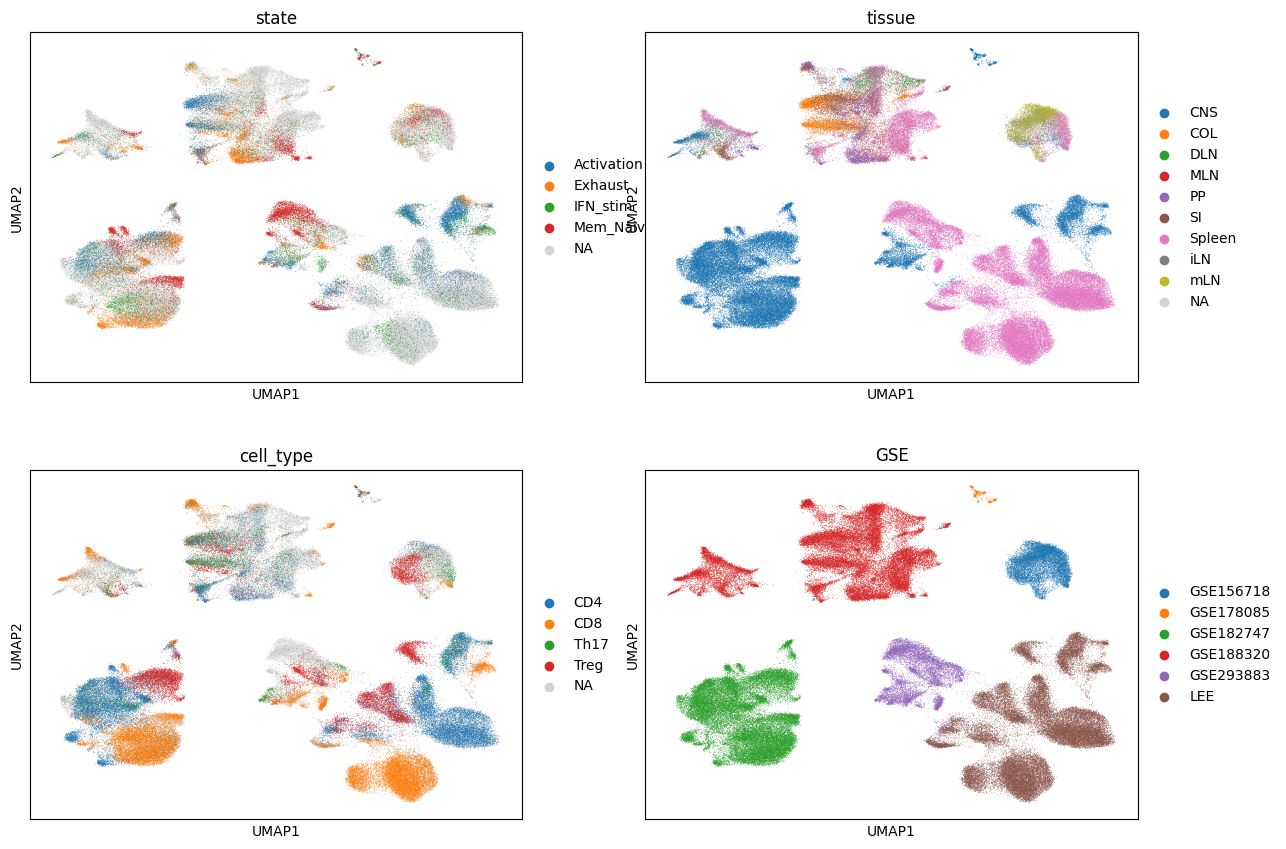

In [12]:
sc.pl.umap(merged["gex"], color=['state', 'tissue', 'cell_type', 'GSE'], ncols=2,)

In [13]:
merged

MuData object with n_obs × n_vars = 142936 × 5000
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'condition', 'sample_id', 'state'
  2 modalities
    gex:	142936 x 5000
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch', 'leiden', 'GSE'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'state_colors', 'tissue_colors', 'cell_type_colors', 'GSE_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	142936 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition'
      obsm:	'airr', 'chain_indices'

### harmony correction

In [14]:
X = np.asarray(merged["gex"].obsm['X_pca'], dtype=np.float64)
bad = ~np.isfinite(X).all(axis=1)
if bad.any():
    merged["gex"] = merged["gex"][~bad].copy()
    X = np.asarray(merged["gex"].obsm['X_pca'], dtype=np.float64)
merged["gex"].obsm['X_pca'] = np.ascontiguousarray(X)

# merged["gex"].obsm['X_pca'] = np.asarray(merged["gex"].obsm['X_pca'], dtype=np.float64)
# merged["gex"].obs['GSE'] = merged["gex"].obs['GSE'].astype("string").fillna("unknown").astype("category")
merged["gex"].obs['GSE'] = merged["gex"].obs['GSE'].astype("object").astype("category")

In [15]:
## Batch correction
import scanpy.external as sce
sce.pp.harmony_integrate(merged["gex"], key=["GSE", 'sample_id'],  basis='X_pca',
                          theta = 3, lamb = 1,  sigma=0.1, nclust = 50, tau=1)

# https://github.com/slowkow/harmonypy/blob/master/harmonypy/harmony.py
# Integration Control Parameters:
# theta: Diversity clustering penalty parameter. A higher value encourages more diverse clusters.
# lamb: Ridge regression penalty parameter. Controls the strength of the regularization applied during the integration step.
# sigma: Width of soft k-means clusters. Influences the fuzziness of cluster assignments.
# nclust: Number of clusters in the model. If None, Harmony will estimate this number.
# tau: Protection against overclustering small datasets with large ones.

# Convergence and Iteration Parameters:
# max_iter_harmony: Maximum number of iterations for the Harmony algorithm if not converged.
# max_iter_cluster: Maximum number of iterations for the k-means clustering step within each Harmony iteration.
# epsilon_harmony: Convergence threshold for the Harmony objective function.
# epsilon_cluster: Convergence threshold for the k-means clustering objective function.
# plot_convergence: Boolean indicating whether to plot the convergence of the objective function. 
# verbose: Boolean indicating whether to print progress messages during execution.
# Other Parameters:
# block_size: Size of data blocks to process if using a block-wise approach.
# reference_values: Optional dictionary specifying reference values for vars_use.
# return_object: Boolean indicating whether to return the full Harmony model object or just the corrected embeddings.

2025-11-03 14:53:19,327 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-03 14:53:33,322 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-03 14:53:33,618 - harmonypy - INFO - Iteration 1 of 10
2025-11-03 14:53:59,613 - harmonypy - INFO - Iteration 2 of 10
2025-11-03 14:54:25,527 - harmonypy - INFO - Iteration 3 of 10
2025-11-03 14:54:50,795 - harmonypy - INFO - Iteration 4 of 10
2025-11-03 14:55:16,105 - harmonypy - INFO - Iteration 5 of 10
2025-11-03 14:55:40,758 - harmonypy - INFO - Iteration 6 of 10
2025-11-03 14:56:05,295 - harmonypy - INFO - Iteration 7 of 10
2025-11-03 14:56:18,992 - harmonypy - INFO - Iteration 8 of 10
2025-11-03 14:56:30,678 - harmonypy - INFO - Iteration 9 of 10
2025-11-03 14:56:42,496 - harmonypy - INFO - Iteration 10 of 10
2025-11-03 14:56:53,146 - harmonypy - INFO - Stopped before convergence


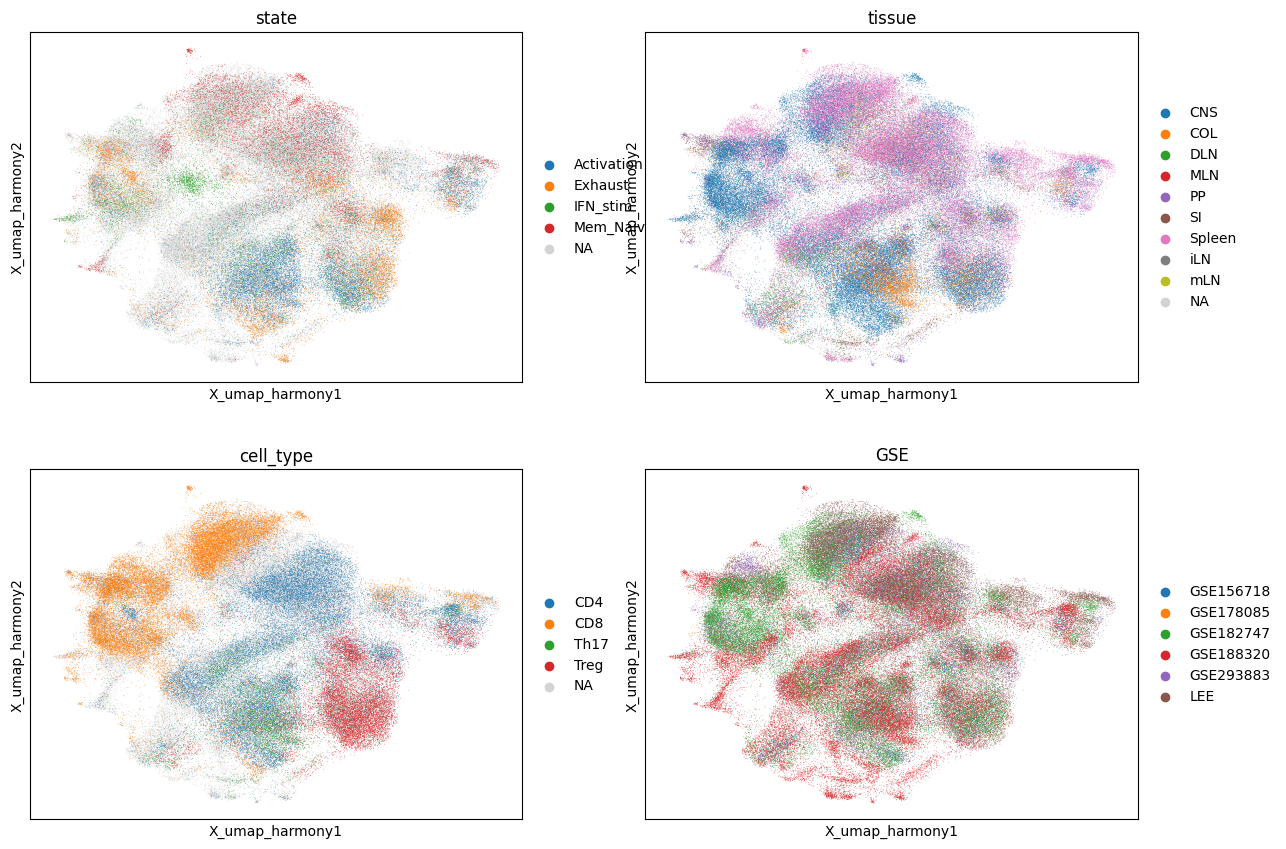

In [16]:
sc.pp.neighbors(merged["gex"], n_neighbors = 30, use_rep='X_pca_harmony', key_added = 'neighbors_harmony')
sc.tl.umap(merged["gex"], min_dist=0.5, spread=1.0, neighbors_key = 'neighbors_harmony', key_added = 'X_umap_harmony')
sc.pl.embedding(merged["gex"], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', 
                color=['state', 'tissue', 'cell_type', 'GSE'], ncols=2,)

In [17]:
import anndata as ad
ad.settings.allow_write_nullable_strings = True
merged.write('merged_EAE.h5mu')